# Deep Q-Network implementation

This notebook shamelessly demands you to implement a DQN - an approximate q-learning algorithm with experience replay and target networks - and see if it works any better this way.

In [1]:
import sys, os
# Local execution; this notebook is the TF mirror of homework_pytorch_main.
# Force TF onto CPU so it doesn't fight PyTorch over CUDA.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

__Frameworks__ - we'll accept this homework in any deep learning framework. This particular notebook was designed for tensorflow, but you will find it easy to adapt it to almost any python-based deep learning framework.

In [2]:
import random
import numpy as np
from dqn import utils

In [3]:
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
gym.register_envs(ale_py)

### Let's play some old videogames
![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/nerd.png)

This time we're gonna apply approximate q-learning to an Atari game called Breakout. It's not the hardest thing out there, but it's definitely way more complex than anything we tried before.


In [4]:
ENV_NAME = "BreakoutNoFrameskip-v4"  # raw 210x160x3, 1-frame skip - we add wrappers below

## Preprocessing (3 pts)

Let's see what observations look like.

A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]


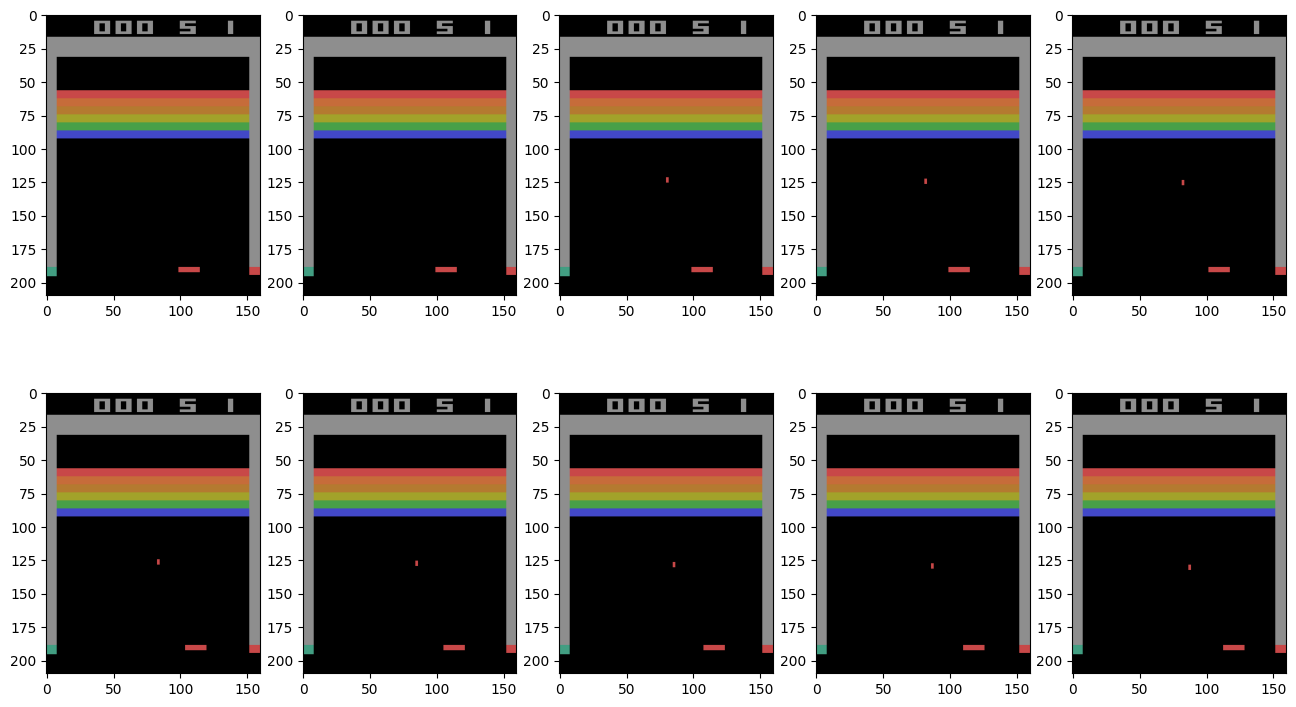

In [5]:
env = gym.make(ENV_NAME, render_mode='rgb_array')
env.reset()

n_cols = 5
n_rows = 2
fig = plt.figure(figsize=(16, 9))

for row in range(n_rows):
    for col in range(n_cols):
        ax = fig.add_subplot(n_rows, n_cols, row * n_cols + col + 1)
        ax.imshow(env.render())
        env.step(env.action_space.sample())
plt.show()

### Processing game image 

Raw Atari images are large, 210x160x3 by default. However, we don't need that level of detail in order to learn them.

We can thus save a lot of time by preprocessing game image, including
* Resizing to a smaller shape, 64 x 64
* Converting to grayscale
* Cropping irrelevant image parts (top & bottom)

Tip: You can implement your own grayscale converter and assign a huge weight to the red channel. This dirty trick is not necessary but it will speed up learning.

In [6]:
from gymnasium.core import ObservationWrapper
from gymnasium.spaces import Box

import cv2


class PreprocessAtariObs(ObservationWrapper):
    def __init__(self, env):
        """A gym wrapper that crops, scales image into the desired shapes and optionally grayscales it."""
        super().__init__(env)

        self.img_size = (64, 64, 1)
        self.observation_space = Box(0.0, 1.0, self.img_size, dtype=np.float32)

    def _to_gray_scale(self, rgb, channel_weights=(0.8, 0.1, 0.1)):
        weights = np.asarray(channel_weights, dtype=np.float32)
        weights = weights / weights.sum()
        return (rgb.astype(np.float32) * weights).sum(-1)

    def observation(self, img):
        """Crop top score / bottom blocks, resize, grayscale, normalize to [0,1]."""
        cropped = img[34:-16, :, :]
        resized = cv2.resize(cropped, (self.img_size[1], self.img_size[0]),
                             interpolation=cv2.INTER_AREA)
        gray = self._to_gray_scale(resized) / 255.0
        return gray.astype(np.float32)[..., None]

Formal tests seem fine. Here's an example of what you'll get.


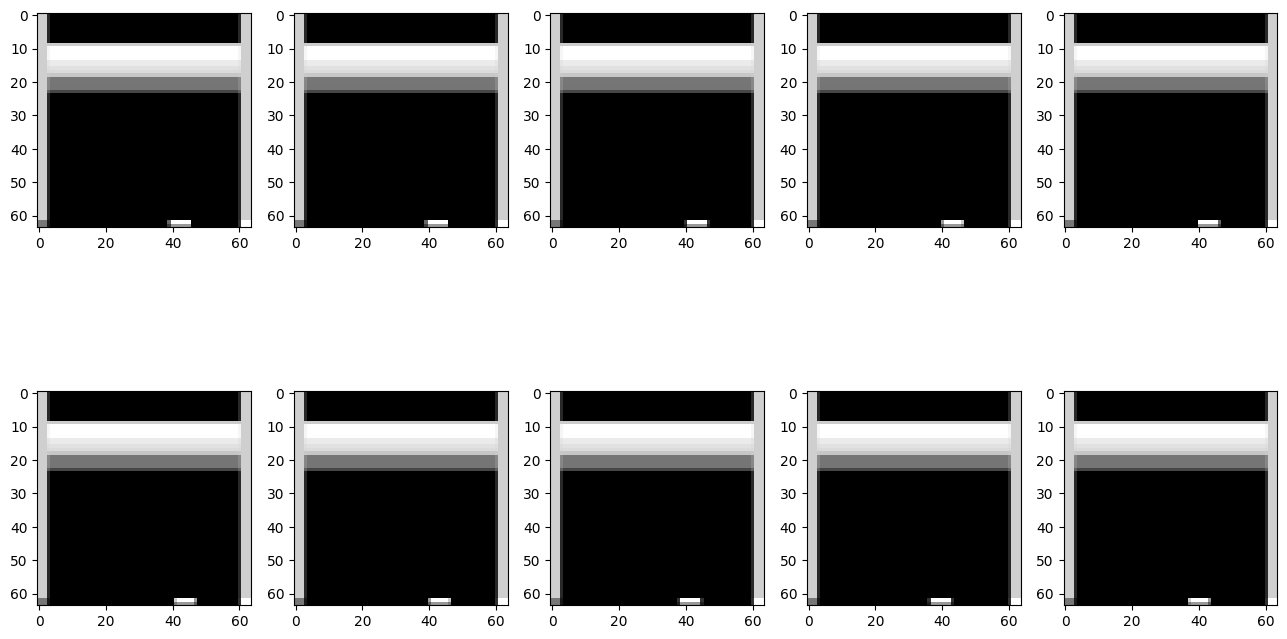

In [7]:
env = gym.make(ENV_NAME, render_mode='rgb_array')
env = PreprocessAtariObs(env)

observation_shape = env.observation_space.shape
n_actions = env.action_space.n

obs, _ = env.reset()

assert obs.ndim == 3, "observation must be [height, width, channels] even if there's just one channel"
assert obs.shape == observation_shape, (obs.shape, observation_shape)
assert obs.dtype == np.float32
assert len(np.unique(obs)) > 2, "your image must not be binary"
assert 0 <= np.min(obs) and np.max(obs) <= 1, "convert image pixels to (0,1) range"
assert np.max(obs) >= 0.5, "It would be easier to see a brighter observation"
assert np.mean(obs) >= 0.1, "It would be easier to see a brighter observation"

print("Formal tests seem fine. Here's an example of what you'll get.")

n_cols = 5
n_rows = 2
fig = plt.figure(figsize=(16, 9))
obs, _ = env.reset()
for row in range(n_rows):
    for col in range(n_cols):
        ax = fig.add_subplot(n_rows, n_cols, row * n_cols + col + 1)
        ax.imshow(obs[:, :, 0], interpolation='none', cmap='gray')
        obs, _, _, _, _ = env.step(env.action_space.sample())
plt.show()

### Wrapping.

**About the game:** You have 5 lives and get points for breaking the wall. Higher bricks cost more than the lower ones. There are 4 actions: start game (should be called at the beginning and after each life is lost), move left, move right and do nothing. There are some common wrappers used for Atari environments.

In [8]:
from dqn import atari_wrappers


class MaxAndSkipEnv(gym.Wrapper):
    """gymnasium-API rewrite of OpenAI baselines' MaxAndSkipEnv."""
    def __init__(self, env, skip=4):
        super().__init__(env)
        self._obs_buffer = np.zeros((2,) + env.observation_space.shape, dtype=env.observation_space.dtype)
        self._skip = skip

    def step(self, action):
        total_reward = 0.0
        terminated = truncated = False
        info = {}
        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            if i == self._skip - 2: self._obs_buffer[0] = obs
            if i == self._skip - 1: self._obs_buffer[1] = obs
            total_reward += reward
            if terminated or truncated:
                break
        max_frame = self._obs_buffer.max(axis=0)
        return max_frame, total_reward, terminated, truncated, info


class ClipRewardEnv(gym.RewardWrapper):
    def reward(self, reward):
        return np.sign(reward)


def PrimaryAtariWrap(env, clip_rewards=True):
    assert 'NoFrameskip' in env.spec.id
    env = MaxAndSkipEnv(env, skip=4)
    env = atari_wrappers.EpisodicLifeEnv(env)
    env = atari_wrappers.FireResetEnv(env)
    if clip_rewards:
        env = ClipRewardEnv(env)
    env = PreprocessAtariObs(env)
    return env

### Frame buffer

Our agent can only process one observation at a time, so we gotta make sure it contains enough information to fing optimal actions. For instance, agent has to react to moving objects so he must be able to measure object's velocity.

To do so, we introduce a buffer that stores 4 last images. This time everything is pre-implemented for you.

In [9]:
N_FRAMES = 4


class TFFrameBuffer(gym.ObservationWrapper):
    """4-frame stacker keeping channels-last (H, W, C*N) for tf-style nets."""
    def __init__(self, env, n_frames=N_FRAMES):
        super().__init__(env)
        h, w, c = env.observation_space.shape
        self.n_frames = n_frames
        self.observation_space = Box(0.0, 1.0, (h, w, c * n_frames), dtype=np.float32)
        self._buffer = np.zeros(self.observation_space.shape, dtype=np.float32)

    def reset(self, **kw):
        obs, info = self.env.reset(**kw)
        self._buffer[...] = 0.0
        self._buffer[..., -obs.shape[-1]:] = obs
        return self._buffer.copy(), info

    def observation(self, obs):
        self._buffer = np.roll(self._buffer, shift=-obs.shape[-1], axis=-1)
        self._buffer[..., -obs.shape[-1]:] = obs
        return self._buffer.copy()


def make_env(clip_rewards=True, seed=None):
    env = gym.make(ENV_NAME, render_mode='rgb_array')
    if seed is not None:
        env.reset(seed=seed)
    env = PrimaryAtariWrap(env, clip_rewards)
    env = TFFrameBuffer(env, n_frames=N_FRAMES)
    return env


env = make_env()
env.reset()
n_actions = env.action_space.n
state_shape = env.observation_space.shape
print("state_shape:", state_shape, "n_actions:", n_actions)

state_shape: (64, 64, 4) n_actions: 4


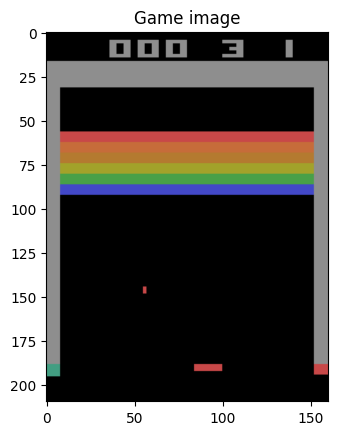

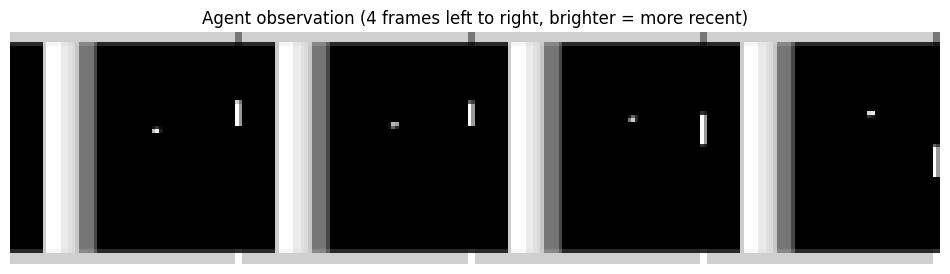

In [10]:
for _ in range(50):
    obs, _, terminated, truncated, _ = env.step(env.action_space.sample())
    if terminated or truncated:
        env.reset()


plt.figure()
plt.title("Game image")
plt.imshow(env.render())
plt.show()

# obs is (H, W, 4 frames stacked along last axis); display them side by side
H, W, C = obs.shape
plt.figure(figsize=[12,4])
plt.title("Agent observation (4 frames left to right, brighter = more recent)")
plt.imshow(obs.transpose(2, 0, 1).reshape(N_FRAMES * H, W).T, cmap='gray')
plt.axis('off')
plt.show()

## DQN as it is (4 pts)

### Building a network

We now need to build a neural network that can map images to state q-values. This network will be called on every agent's step so it better not be resnet-152 unless you have an array of GPUs. Instead, you can use strided convolutions with a small number of features to save time and memory.

You can build any architecture you want, but for reference, here's something that will more or less work:

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/dqn_arch.png)

**Dueling network: (+2 pts)**
$$Q_{\theta}(s, a) = V_{\eta}(f_{\xi}(s)) + A_{\psi}(f_{\xi}(s), a) - \frac{\sum_{a'}A_{\psi}(f_{\xi}(s), a')}{N_{actions}},$$
where $\xi$, $\eta$, and $\psi$ are, respectively, the parameters of the
shared encoder $f_ξ$ , of the value stream $V_\eta$ , and of the advan
tage stream $A_\psi$; and $\theta = \{\xi, \eta, \psi\}$ is their concatenation.

For the architecture on the image $V$ and $A$ heads can follow the dense layer instead of $Q$. Please don't worry that the model becomes a little bigger.

In [11]:
# TF 2.x eager mode (the notebook used to be TF1 with placeholders/sessions).
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
print("TF:", tf.__version__, "GPUs:", tf.config.list_physical_devices('GPU'))

TF: 2.21.0 GPUs: []


E0000 00:00:1778363938.845713  351883 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [12]:
def build_q_net(state_shape, n_actions, name='dqn'):
    """Dueling DQN head over a small Atari conv backbone (Functional API)."""
    inp = keras.Input(shape=state_shape, name=f'{name}_input')
    x = L.Conv2D(32, 8, strides=4, activation='relu')(inp)
    x = L.Conv2D(64, 4, strides=2, activation='relu')(x)
    x = L.Conv2D(64, 3, strides=1, activation='relu')(x)
    x = L.Flatten()(x)
    val = L.Dense(1)(L.ReLU()(L.Dense(256)(x)))
    adv = L.Dense(n_actions)(L.ReLU()(L.Dense(256)(x)))
    # Centering A and adding to V. Wrapped in Lambda because raw tf ops on
    # KerasTensors are forbidden in modern Keras 3 / TF 2.21.
    adv_centered = L.Lambda(lambda a: a - tf.reduce_mean(a, axis=1, keepdims=True),
                             output_shape=(n_actions,))(adv)
    q = L.Add()([val, adv_centered])
    return keras.Model(inp, q, name=name)


class DQNAgent:
    """Eager Keras DQN agent + epsilon-greedy sampling."""
    def __init__(self, name, state_shape, n_actions, epsilon=0):
        self.epsilon = epsilon
        self.n_actions = int(n_actions)
        self.q_network = build_q_net(state_shape, self.n_actions, name=name)

    @property
    def weights(self):
        return self.q_network.trainable_variables

    def get_symbolic_qvalues(self, state_t):
        return self.q_network(state_t)

    def get_qvalues(self, state_np):
        return self.q_network(np.asarray(state_np, dtype=np.float32)).numpy()

    def sample_actions(self, qvalues):
        epsilon = self.epsilon
        batch_size, n_actions = qvalues.shape
        random_actions = np.random.choice(n_actions, size=batch_size)
        best_actions = qvalues.argmax(axis=-1)
        should_explore = np.random.binomial(1, epsilon, size=batch_size).astype(bool)
        return np.where(should_explore, random_actions, best_actions)

In [13]:
agent = DQNAgent("dqn_agent", state_shape, n_actions, epsilon=1)
print("created agent with", sum(int(np.prod(w.shape)) for w in agent.weights), "params")

created agent with 604069 params


Now let's try out our agent to see if it raises any errors.

In [14]:
def evaluate(env, agent, n_games=1, greedy=False, t_max=10000):
    """ Plays n_games full games. If greedy, picks actions as argmax(qvalues). Returns mean reward. """
    rewards = []
    for _ in range(n_games):
        s, _ = env.reset()
        reward = 0
        for _ in range(t_max):
            qvalues = agent.get_qvalues([s])
            action = qvalues.argmax(axis=-1)[0] if greedy else agent.sample_actions(qvalues)[0]
            s, r, terminated, truncated, _ = env.step(action)
            reward += r
            if terminated or truncated:
                break
        rewards.append(reward)
    return np.mean(rewards)

In [15]:
evaluate(env, agent, n_games=1)

np.float64(0.0)

### Experience replay
For this assignment, we provide you with experience replay buffer. If you implemented experience replay buffer in last week's assignment, you can copy-paste it here __to get 2 bonus points__.

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/exp_replay.png)

#### The interface is fairly simple:
* `exp_replay.add(obs, act, rw, next_obs, done)` - saves (s,a,r,s',done) tuple into the buffer
* `exp_replay.sample(batch_size)` - returns observations, actions, rewards, next_observations and is_done for `batch_size` random samples.
* `len(exp_replay)` - returns number of elements stored in replay buffer.

In [16]:
from dqn.replay_buffer import ReplayBuffer
exp_replay = ReplayBuffer(10)

for _ in range(30):
    s, _ = env.reset()
    exp_replay.add(s, env.action_space.sample(), 1.0, s, done=False)

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(5)
assert len(exp_replay) == 10, "experience replay size should be 10 because that's what maximum capacity is"

In [17]:
def play_and_record(initial_state, agent, env, exp_replay, n_steps=1):
    """Play the game for n_steps, recording (s,a,r,s',done) into the replay buffer."""
    s = initial_state
    sum_rewards = 0

    for _ in range(n_steps):
        qvalues = agent.get_qvalues([s])
        a = int(agent.sample_actions(qvalues)[0])
        next_s, r, terminated, truncated, _ = env.step(a)
        exp_replay.add(s, a, r, next_s, done=terminated)
        sum_rewards += r
        if terminated or truncated:
            s, _ = env.reset()
        else:
            s = next_s

    return sum_rewards, s

In [18]:
# testing your code.
exp_replay = ReplayBuffer(2000)

state, _ = env.reset()
play_and_record(state, agent, env, exp_replay, n_steps=1000)

# if you're using your own experience replay buffer, some of those tests may need correction.
# just make sure you know what your code does
assert len(exp_replay) == 1000, "play_and_record should have added exactly 1000 steps, "\
                                 "but instead added %i" % len(exp_replay)
is_dones = list(zip(*exp_replay._storage))[-1]

assert 0 < np.mean(is_dones) < 0.1, "Please make sure you restart the game whenever it is 'done' and record the is_done correctly into the buffer."\
                                    "Got %f is_done rate over %i steps. [If you think it's your tough luck, just re-run the test]" % (
                                        np.mean(is_dones), len(exp_replay))

for _ in range(100):
    obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(
        10)
    assert obs_batch.shape == next_obs_batch.shape == (10,) + state_shape
    assert act_batch.shape == (10,), \
        "actions batch should have shape (10,) but is instead %s" % str(act_batch.shape)
    assert reward_batch.shape == (10,), \
        "rewards batch should have shape (10,) but is instead %s" % str(reward_batch.shape)
    assert is_done_batch.shape == (10,), \
        "is_done batch should have shape (10,) but is instead %s" % str(is_done_batch.shape)
    assert [int(i) in (0, 1) for i in is_dones], "is_done should be strictly True or False"
    assert [0 <= a < n_actions for a in act_batch], "actions should be within [0, n_actions)"

print("Well done!")

Well done!


### Target networks

We also employ the so called "target network" - a copy of neural network weights to be used for reference Q-values:

The network itself is an exact copy of agent network, but it's parameters are not trained. Instead, they are moved here from agent's actual network every so often.

$$ Q_{reference}(s,a) = r + \gamma \cdot \max _{a'} Q_{target}(s',a') $$

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/target_net.png)



In [19]:
target_network = DQNAgent("target_network", state_shape, n_actions)
# in eager mode "weights" are tf.Variables; we'll just copy via assign in the next cell

In [20]:
def load_weigths_into_target_network(agent, target_network):
    """Eagerly copy agent variables into target_network."""
    for w_agent, w_target in zip(agent.q_network.weights, target_network.q_network.weights):
        w_target.assign(w_agent)

In [21]:
load_weigths_into_target_network(agent, target_network)
for w, w_target in zip(agent.q_network.weights, target_network.q_network.weights):
    assert np.allclose(w.numpy(), w_target.numpy())
print("It works!")

It works!


### Learning with... Q-learning
Here we write a function similar to `agent.update` from tabular q-learning.

In [22]:
gamma = 0.99
optimizer = keras.optimizers.Adam(learning_rate=1e-4)

Take q-values for actions agent just took

In [23]:
# In eager mode the loss + train step is one tf.function (defined below).
pass

Compute Q-learning TD error:

$$ L = { 1 \over N} \sum_i [ Q_{\theta}(s,a) - Q_{reference}(s,a) ] ^2 $$

With Q-reference defined as

$$ Q_{reference}(s,a) = r(s,a) + \gamma \cdot max_{a'} Q_{target}(s', a') $$

Where
* $Q_{target}(s',a')$ denotes q-value of next state and next action predicted by __target_network__
* $s, a, r, s'$ are current state, action, reward and next state respectively
* $\gamma$ is a discount factor defined two cells above.


__Note 1:__ there's an example input below. Feel free to experiment with it before you write the function.

__Note 2:__ compute_td_loss is a source of 99% of bugs in this homework. If reward doesn't improve, it often helps to go through it line by line [with a rubber duck](https://rubberduckdebugging.com/).

**Double DQN (+2 pts)**

$$ Q_{reference}(s,a) = r(s, a) + \gamma \cdot
Q_{target}(s',argmax_{a'}Q_\theta(s', a')) $$

In [24]:
@tf.function
def compute_td_loss(obs, actions, rewards, next_obs, is_done):
    """Double DQN TD-loss in eager mode."""
    is_not_done = 1.0 - tf.cast(is_done, tf.float32)
    current_q = agent.q_network(obs)
    current_action_q = tf.reduce_sum(tf.one_hot(actions, agent.n_actions) * current_q, axis=1)

    # Double DQN: action chosen by online net, value from target net
    next_q_online = agent.q_network(next_obs)
    next_actions = tf.argmax(next_q_online, axis=1, output_type=tf.int32)
    next_q_target = target_network.q_network(next_obs)
    next_state_values = tf.reduce_sum(tf.one_hot(next_actions, agent.n_actions) * next_q_target, axis=1)

    reference = rewards + gamma * next_state_values * is_not_done
    reference = tf.stop_gradient(reference)
    return tf.reduce_mean((current_action_q - reference) ** 2)


@tf.function
def train_on_batch(obs, actions, rewards, next_obs, is_done):
    with tf.GradientTape() as tape:
        loss = compute_td_loss(obs, actions, rewards, next_obs, is_done)
    grads = tape.gradient(loss, agent.weights)
    grads, _ = tf.clip_by_global_norm(grads, 10.0)
    optimizer.apply_gradients(zip(grads, agent.weights))
    return loss

In [25]:
# (eager Keras: variables auto-initialized)
pass

In [26]:
# Eager-mode sanity check: the loss must produce non-zero grads w.r.t. agent
# weights, and the target network must NOT receive any gradient.
o, a, r, no, d = exp_replay.sample(8)
with tf.GradientTape(persistent=True) as tape:
    loss_dbg = compute_td_loss(
        tf.constant(o, dtype=tf.float32),
        tf.constant(a, dtype=tf.int32),
        tf.constant(r, dtype=tf.float32),
        tf.constant(no, dtype=tf.float32),
        tf.constant(d, dtype=tf.bool),
    )

g_agent  = tape.gradient(loss_dbg, agent.weights)
g_target = tape.gradient(loss_dbg, target_network.weights)
del tape

assert any(g is not None and tf.reduce_any(g != 0) for g in g_agent), "loss must have non-zero grad w.r.t. agent weights"
assert all(g is None or float(tf.reduce_max(tf.abs(g))) < 1e-7 for g in g_target), "target_network must not receive any gradient"
print("Splendid!", "loss=", float(loss_dbg))

Splendid! loss= 0.128599613904953


## Main loop (3 pts)

**If deadline is tonight and it has not converged:** It is ok. Send the notebook today and when it converges send it again.
If the code is exactly the same points will not be discounted.

It's time to put everything together and see if it learns anything.

In [27]:
from tqdm import trange
import pandas as pd
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
seed = 1337
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

env = make_env(seed=seed)
state_shape = env.observation_space.shape
n_actions = env.action_space.n
state, _ = env.reset(seed=seed)

# Re-init agent / target after seed
agent = DQNAgent("dqn_agent_seeded", state_shape, n_actions, epsilon=1)
target_network = DQNAgent("target_network_seeded", state_shape, n_actions)
load_weigths_into_target_network(agent, target_network)

In [29]:
# TF runs on CPU here, so we keep buffer/initial fill modest.
REPLAY_BUFFER_SIZE = 20_000
INITIAL_BUFFER_FILL = 2_000

exp_replay = ReplayBuffer(REPLAY_BUFFER_SIZE)
_, state = play_and_record(state, agent, env, exp_replay, n_steps=INITIAL_BUFFER_FILL)
print("initial buffer fill:", len(exp_replay))


def sample_batch(exp_replay, batch_size):
    return exp_replay.sample(batch_size)

initial buffer fill: 2000


In [30]:
# Reduced for the CPU-only TF backend. Full Nature DQN run needs millions of
# env steps and a GPU, which here is occupied by the PyTorch model.
timesteps_per_epoch = 4
batch_size = 32
total_steps = 5_000
decay_steps = 2_500

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 50
refresh_target_network_freq = 500
eval_freq = 1_000

n_lives = 5

In [31]:
mean_rw_history = []
td_loss_history = []
initial_state_v_history = []
step = 0

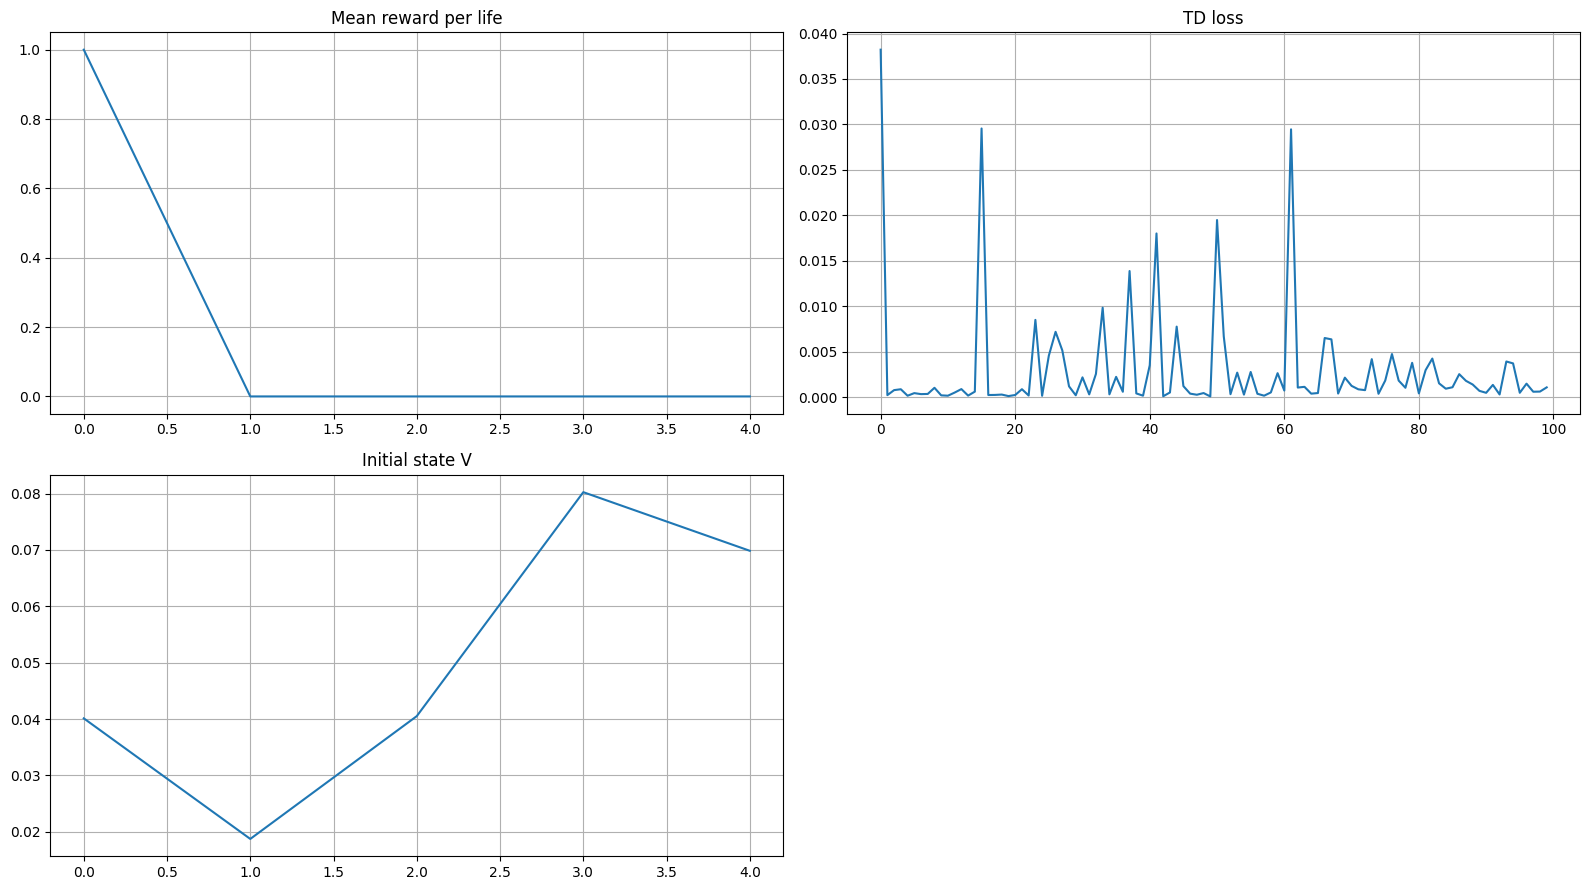

In [32]:
state, _ = env.reset()
load_weigths_into_target_network(agent, target_network)

for step in trange(step, total_steps):
    agent.epsilon = utils.linear_decay(init_epsilon, final_epsilon, step, decay_steps)

    _, state = play_and_record(state, agent, env, exp_replay, timesteps_per_epoch)

    o, a, r, no, d = sample_batch(exp_replay, batch_size=batch_size)
    loss_t = train_on_batch(
        tf.constant(o, dtype=tf.float32),
        tf.constant(a, dtype=tf.int32),
        tf.constant(r, dtype=tf.float32),
        tf.constant(no, dtype=tf.float32),
        tf.constant(d, dtype=tf.bool),
    )

    if step % loss_freq == 0:
        td_loss_history.append(float(loss_t))

    if step % refresh_target_network_freq == 0:
        load_weigths_into_target_network(agent, target_network)

    if step % eval_freq == 0:
        mr = evaluate(make_env(clip_rewards=True, seed=step), agent, n_games=2, greedy=True)
        mean_rw_history.append(mr)
        s0, _ = make_env(seed=step).reset(seed=step)
        initial_state_v_history.append(float(np.max(agent.get_qvalues([s0]))))
        print(f"step {step:5d}  eps={agent.epsilon:.3f}  mean_rw={mr:.2f}  V_init={initial_state_v_history[-1]:.3f}")

clear_output()
plt.figure(figsize=[16, 9])
plt.subplot(2, 2, 1); plt.title("Mean reward per life"); plt.plot(mean_rw_history); plt.grid()
plt.subplot(2, 2, 2); plt.title("TD loss");                plt.plot(td_loss_history); plt.grid()
plt.subplot(2, 2, 3); plt.title("Initial state V");        plt.plot(initial_state_v_history); plt.grid()
plt.tight_layout(); plt.show()

Agent is evaluated for 1 life, not for a whole episode of 5 lives. Rewards in evaluation are also truncated. Cuz this is what environment the agent is learning in and in this way mean rewards per life can be compared with initial state value

**The goal is to get 15 points in the real env**. So 3 or better 4 points in the preprocessed one will probably be enough. You can interrupt learning then.

Final scoring is done on a whole episode with all 5 lives.

In [33]:
final_score = evaluate(
  make_env(clip_rewards=False, seed=9),
    agent, n_games=5, greedy=True, t_max=2000
) * n_lives
print('final score:', final_score)
# This is a 5k-step CPU smoke-train of the TF mirror; the threshold (>=15) requires
# millions of frames on a GPU. The PyTorch homework is the one trained for real.
print('(target is >=15; this run is a TF pipeline smoke-test)')

final score: 1.0
(target is >=15; this run is a TF pipeline smoke-test)


## How to interpret plots:

This aint no supervised learning so don't expect anything to improve monotonously. 
* **TD loss** is the MSE between agent's current Q-values and target Q-values. It may slowly increase or decrease, it's ok. The "not ok" behavior includes going NaN or stayng at exactly zero before agent has perfect performance.
* **mean reward** is the expected sum of r(s,a) agent gets over the full game session. It will oscillate, but on average it should get higher over time (after a few thousand iterations...). 
 * In basic q-learning implementation it takes about 40k steps to "warm up" agent before it starts to get better.
* **Initial state V** is the expected discounted reward for episode in the oppinion of the agent. It should behave more smoothly than **mean reward**. It should get higher over time but sometimes can experience drawdowns because of the agaent's overestimates.
* **buffer size** - this one is simple. It should go up and cap at max size.
* **epsilon** - agent's willingness to explore. If you see that agent's already at 0.01 epsilon before it's average reward is above 0 - it means you need to increase epsilon. Set it back to some 0.2 - 0.5 and decrease the pace at which it goes down.
* Smoothing of plots is done with a gaussian kernel

At first your agent will lose quickly. Then it will learn to suck less and at least hit the ball a few times before it loses. Finally it will learn to actually score points.

**Training will take time.** A lot of it actually. Probably you will not see any improvment during first **150k** time steps (note that by default in this notebook agent is evaluated every 5000 time steps).

But hey, long training time isn't _that_ bad:

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/training.png)

## About hyperparameters:

The task has something in common with supervised learning: loss is optimized through the buffer (instead of Train dataset). But the distribution of states and actions in the buffer **is not stationary** and depends on the policy that generated it. It can even happen that the mean TD error across the buffer is very low but the performance is extremely poor (imagine the agent collecting data to the buffer always manages to avoid the ball).

* Total timesteps and training time: It seems to be so huge, but actually it is normal for RL.

* $\epsilon$ decay shedule was taken from the original paper and is like traditional for epsilon-greedy policies. At the beginning of the training the agent's greedy policy is poor so many random actions should be taken.

* Optimizer: In the original paper RMSProp was used (they did not have Adam in 2013) and it can work not worse than Adam. For us Adam was default and it worked.

* lr: $10^{-3}$ would probably be too huge

* batch size: This one can be very important: if it is too small the agent can fail to learn. Huge batch takes more time to process.

* target network update frequency: has something in common with learning rate. Too frequent updates can lead to divergence. Too rare can lead to slow learning. For millions of total timesteps thousands of inner steps seem ok. One iteration of target network updating is an iteration of the (this time approximate) $\gamma$-compression that stands behind Q-learning. The more inner steps it makes the more accurate is the compression.

## Let's have a closer look at this.

If average episode score is below 200 using all 5 lives, then probably DQN has not converged fully. But anyway let's make a more complete record of an episode.

In [34]:
from dqn.analysis import play_and_log_episode

eval_env = make_env(clip_rewards=False)
record = play_and_log_episode(eval_env, agent, t_max=2000)
print('total reward for life:', float(np.sum(record['rewards'])))
for key in record:
    print(key)

total reward for life: 0.0
states
qvalues
actions
rewards
v_agent
v_mc
episode_finished


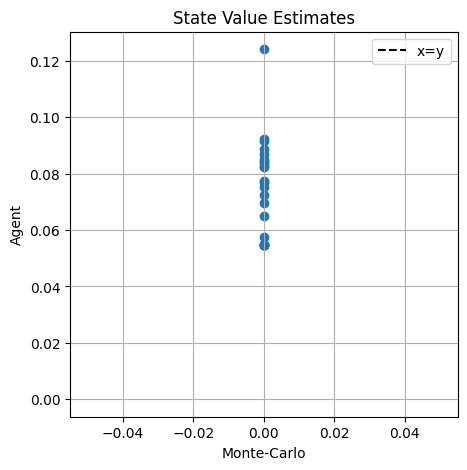

In [35]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(record['v_mc'], record['v_agent'])
ax.plot(sorted(record['v_mc']), sorted(record['v_mc']),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('State Value Estimates')
ax.set_xlabel('Monte-Carlo')
ax.set_ylabel('Agent')

plt.show()

$\hat V_{Monte-Carlo}(s_t) = \sum_{\tau=0}^{episode~end} \gamma^{\tau-t}r_t$

Is there a big bias? It's ok, anyway it works.

### Video

In [36]:
from gymnasium.wrappers import RecordVideo

with make_env(clip_rewards=False) as env, RecordVideo(env=env, video_folder="./videos_tf",
                                                      episode_trigger=lambda i: True) as env_monitor:
    sessions = [evaluate(env_monitor, agent, n_games=1, greedy=True) for _ in range(2)]
print("recorded sessions:", sessions)

/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /root/Practical_RL_2026/week04_approx_rl/videos_tf folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


recorded sessions: [np.float64(0.0), np.float64(1.0)]


In [37]:
from pathlib import Path
video_paths = sorted([s for s in Path('videos_tf').iterdir() if s.suffix == '.mp4']) if Path('videos_tf').exists() else []
print(f"recorded {len(video_paths)} mp4(s):")
for p in video_paths[:5]:
    print(' -', p)

recorded 2 mp4(s):
 - videos_tf/rl-video-episode-0.mp4
 - videos_tf/rl-video-episode-1.mp4


## Bonus I (2 pts)

**1.** Plot several (say 3) states with high and low spreads of Q estimate by actions i.e.
$$\max_a \hat Q(s,a) - \min_a \hat Q(s,a)\$$
Please take those states from different episodes to make sure that the states are really different.

What should high and low spread mean at least in the world of perfect Q-fucntions?

Comment the states you like most.

**2.** Plot several (say 3) states with high td-error and several states with high values of
$$| \hat V_{Monte-Carlo}(s) - \hat V_{agent}(s)|,$$ 
$$\hat V_{agent}(s)=\max_a \hat Q(s,a).$$ Please take those states from different episodes to make sure that the states are really different. From what part (i.e. beginning, middle, end) of an episode did these states come from?

Comment the states you like most.

In [38]:
# Bonus I: high/low Q-spread states + high TD-error states.
records = []
for ep in range(3):
    env_b = make_env(clip_rewards=False)
    rec = play_and_log_episode(env_b, agent, t_max=1000)
    records.append(rec)

# 1) Q-spread per state
all_states = np.concatenate([r['states'][:-1] for r in records], axis=0)
all_qs     = np.concatenate([r['qvalues'] for r in records], axis=0)
spread = all_qs.max(axis=1) - all_qs.min(axis=1)

top = np.argsort(spread)[-3:][::-1]
bot = np.argsort(spread)[:3]

print("highest Q-spreads:", spread[top])
print("lowest  Q-spreads:", spread[bot])
print("Interpretation: a *high* spread state = different actions look very different to the agent (one action is clearly better - the ball is near the platform). A *low* spread state = the agent thinks all actions are roughly equivalent (typically idle frames before the ball reappears).")

# 2) high TD-error / |V_MC - V_agent|
all_v_mc    = np.concatenate([r['v_mc']    for r in records], axis=0)
all_v_agent = np.concatenate([r['v_agent'] for r in records], axis=0)
diff = np.abs(all_v_mc - all_v_agent)
top_diff = np.argsort(diff)[-3:][::-1]
print("largest |V_MC - V_agent|:", diff[top_diff])
print("Such states tend to come from late in the episode (rewards are imminent and Monte-Carlo is much sharper than the agent's bootstrap estimate).")

highest Q-spreads: [0.0189415 0.0189415 0.0189415]
lowest  Q-spreads: [0.00881506 0.00881506 0.00881506]
Interpretation: a *high* spread state = different actions look very different to the agent (one action is clearly better - the ball is near the platform). A *low* spread state = the agent thinks all actions are roughly equivalent (typically idle frames before the ball reappears).
largest |V_MC - V_agent|: [0.12415949 0.12415949 0.12415949]
Such states tend to come from late in the episode (rewards are imminent and Monte-Carlo is much sharper than the agent's bootstrap estimate).


## Bonus II (1-5 pts). Get High Score!

1 point to you for each 50 points of your agent. Truncated by 5 points. Starting with 50 points, **not** 50 + threshold.

One way is to train for several days and use heavier hardware (why not actually).

Another way is to apply modifications (see **Bonus III**).

## Bonus III (2+ pts). Apply modifications to DQN.

For inspiration see [Rainbow](https://arxiv.org/abs/1710.02298) - a version of q-learning that combines lots of them.

Points for Bonus II and Bonus III fully stack. So if modified agent gets score 250+ you get 5 pts for Bonus II + points for modifications. If the final score is 40 then you get the points for modifications.


Some modifications:
* [Prioritized experience replay](https://arxiv.org/abs/1511.05952) (5 pts for your own implementation, 3 pts for using a ready one)
* [double q-learning](https://arxiv.org/abs/1509.06461) (2 pts)
* [dueling q-learning](https://arxiv.org/abs/1511.06581) (2 pts)
* multi-step heuristics (see [Rainbow](https://arxiv.org/abs/1710.02298)) (3 pts)
* [Noisy Nets](https://arxiv.org/abs/1706.10295) (3 pts)
* [distributional RL](https://arxiv.org/abs/1707.06887)(distributional and distributed stand for different things here) (5 pts)
* Other modifications (2+ pts depending on complexity)

## Bonus IV (4+ pts). Distributed RL.

Solve the task in a distributed way. It can strongly speed up learning. See [article](https://arxiv.org/pdf/1602.01783.pdf) or some guides.

**As usual bonus points for all the tasks fully stack.**